In [4]:

  import os
  import matplotlib.pyplot as plt
  import cv2
  import random
  from pathlib import Path

  # Define paths
  BASE_DIR = Path(r"C:\Users\AadithGeethMohan\OneDrive\Desktop\ACM SIGKDD TASK\pothole-detection")
  DATASET_DIR = BASE_DIR / "Pothole Detection.v1i.yolov8-obb"
  TRAIN_IMAGES = DATASET_DIR / "train" / "images"
  TRAIN_LABELS = DATASET_DIR / "train" / "labels"
  VAL_IMAGES = DATASET_DIR / "valid" / "images"
  VAL_LABELS = DATASET_DIR / "valid" / "labels"

  # Count files
  train_images = list(TRAIN_IMAGES.glob("*.jpg")) + list(TRAIN_IMAGES.glob("*.png"))
  train_labels = list(TRAIN_LABELS.glob("*.txt"))
  val_images = list(VAL_IMAGES.glob("*.jpg")) + list(VAL_IMAGES.glob("*.png"))
  val_labels = list(VAL_LABELS.glob("*.txt"))

  train_pct = len(train_images) / (len(train_images) + len(val_images)) * 100
  val_pct = len(val_images) / (len(train_images) + len(val_images)) * 100

  print("=" * 50)
  print("DATASET SUMMARY")
  print("=" * 50)
  print(f"Training images:   {len(train_images)}")
  print(f"Training labels:   {len(train_labels)}")
  print(f"Validation images: {len(val_images)}")
  print(f"Validation labels: {len(val_labels)}")
  print(f"Train-Val split:   {train_pct:.1f}% / {val_pct:.1f}%")

  # Check a sample label file
  print("\n" + "=" * 50)
  print("SAMPLE LABEL FILE (OBB format - 9 values per box)")
  print("=" * 50)
  sample_label_file = TRAIN_LABELS / train_labels[0].name
  with open(sample_label_file, 'r') as f:
      content = f.read()
  print(f"File: {sample_label_file.name}")
  print(f"Content:\n{content}")
  print("Format: class_id x1 y1 x2 y2 x3 y3 x4 y4 (rotated box vertices)")

DATASET SUMMARY
Training images:   1035
Training labels:   1035
Validation images: 273
Validation labels: 273
Train-Val split:   79.1% / 20.9%

SAMPLE LABEL FILE (OBB format - 9 values per box)
File: 001_png.rf.ab7eb60daac337d0c86df968d9e55432.txt
Content:
0 0.415625 0.3664772727272728 0.284375 0.3664772727272727 0.284375 0.434659090909091 0.415625 0.43465909090909105
0 0.996875 0.37500000000000017 0.71875 0.37500000000000017 0.71875 0.8295454545454547 0.996875 0.8295454545454549
0 0.471875 0.14204545454545464 0.396875 0.1420454545454546 0.396875 0.16761363636363646 0.471875 0.1676136363636365
0 0.4234375 0.16477272727272735 0.2984375 0.16477272727272735 0.2984375 0.20738636363636373 0.4234375 0.20738636363636373
0 0.4203125 0.25852272727272735 0.353125 0.25852272727272735 0.353125 0.2954545454545455 0.4203125 0.2954545454545455
Format: class_id x1 y1 x2 y2 x3 y3 x4 y4 (rotated box vertices)


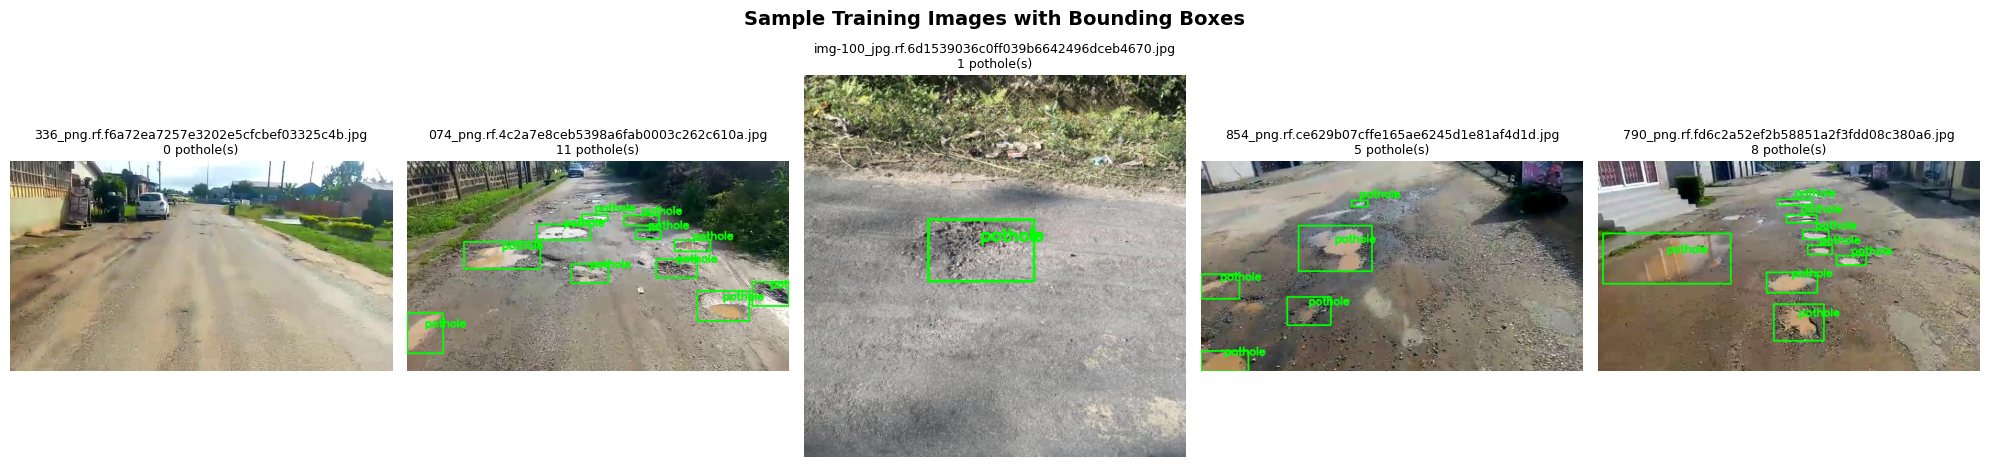

In [6]:

  import numpy as np

  def draw_obb(image, label_path, class_names=['pothole']):
      """Draw OBB (oriented bounding boxes) on image."""
      img = image.copy()
      h, w = img.shape[:2]

      with open(label_path, 'r') as f:
          lines = f.readlines()

      for line in lines:
          parts = line.strip().split()
          if len(parts) == 9:
              class_id = int(parts[0])
              coords = [float(p) for p in parts[1:]]
              points = np.array(coords).reshape(4, 2)
              points[:, 0] *= w
              points[:, 1] *= h
              points = points.astype(np.int32)
              color = (0, 255, 0)
              cv2.polylines(img, [points], isClosed=True, color=color, thickness=2)
              cx, cy = points.mean(axis=0)
              label = class_names[class_id] if class_id < len(class_names) else "class_" + str(class_id)
              cv2.putText(img, label, (int(cx), int(cy) - 10),
                          cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)
      return img

  # Visualize 5 random training images
  fig, axes = plt.subplots(1, 5, figsize=(20, 5))
  random.seed(42)

  sample_images = random.sample(train_images, 5)

  for i, img_path in enumerate(sample_images):
      label_path = TRAIN_LABELS / (img_path.stem + ".txt")

      img = cv2.imread(str(img_path))
      img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

      box_count = 0
      if label_path.exists():
          with open(label_path) as f:
              box_count = len(f.readlines())
          img = draw_obb(img, label_path)

      title = img_path.name + "\n" + str(box_count) + " pothole(s)"
      axes[i].imshow(img)
      axes[i].set_title(title, fontsize=9)
      axes[i].axis("off")

  plt.suptitle("Sample Training Images with Bounding Boxes", fontsize=14, fontweight='bold')
  plt.tight_layout()
  plt.show()

In [7]:

  # Analyze potholes per image distribution
  pothole_counts = []

  for label_file in train_labels:
      with open(label_file, 'r') as f:
          count = len(f.readlines())
      pothole_counts.append(count)

  unique_counts = sorted(set(pothole_counts))
  count_freq = {c: pothole_counts.count(c) for c in unique_counts}

  print("=" * 50)
  print("POTHOLES PER IMAGE DISTRIBUTION (Training Set)")
  print("=" * 50)
  for c, freq in sorted(count_freq.items()):
      bar = "#" * freq
      print(f"{c} pothole(s): {freq:4d} images ({freq/len(train_labels)*100:5.1f}%) {bar}")

  print(f"\nTotal images:       {len(pothole_counts)}")
  print(f"Min potholes/image: {min(pothole_counts)}")
  print(f"Max potholes/image: {max(pothole_counts)}")
  print(f"Avg potholes/image: {sum(pothole_counts)/len(pothole_counts):.2f}")
  print(f"Total potholes:     {sum(pothole_counts)}")

POTHOLES PER IMAGE DISTRIBUTION (Training Set)
0 pothole(s):   94 images (  9.1%) ##############################################################################################
1 pothole(s):  255 images ( 24.6%) ###############################################################################################################################################################################################################################################################
2 pothole(s):  170 images ( 16.4%) ##########################################################################################################################################################################
3 pothole(s):  150 images ( 14.5%) ######################################################################################################################################################
4 pothole(s):   82 images (  7.9%) ##################################################################################
5 pothole(s):  100 ima

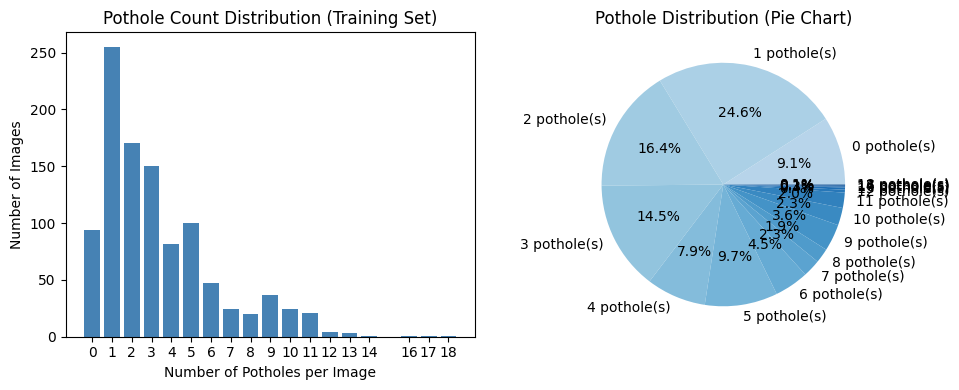

In [12]:
# Plot the distribution
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.bar(count_freq.keys(), count_freq.values(), color='steelblue')
plt.xlabel("Number of Potholes per Image")
plt.ylabel("Number of Images")
plt.title("Pothole Count Distribution (Training Set)")
plt.xticks(sorted(count_freq.keys()))

plt.subplot(1, 2, 2)
plt.pie(count_freq.values(), labels=[str(k) + " pothole(s)" for k in count_freq.keys()],
    autopct='%1.1f%%', colors=plt.cm.Blues(np.linspace(0.3, 0.9, len(count_freq))))
plt.title("Pothole Distribution (Pie Chart)")

plt.tight_layout()
plt.show()

In [5]:

  from pathlib import Path

  BASE_DIR = Path(r"C:\Users\AadithGeethMohan\OneDrive\Desktop\ACM SIGKDD TASK\pothole-detection")
  DATASET_DIR = BASE_DIR / "Pothole Detection.v1i.yolov8-obb"

  import os
  os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

  print("BASE_DIR:", BASE_DIR)
  print("Dataset:", DATASET_DIR)
  print("data.yaml exists:", (BASE_DIR / "data.yaml").exists())

BASE_DIR: C:\Users\AadithGeethMohan\OneDrive\Desktop\ACM SIGKDD TASK\pothole-detection
Dataset: C:\Users\AadithGeethMohan\OneDrive\Desktop\ACM SIGKDD TASK\pothole-detection\Pothole Detection.v1i.yolov8-obb
data.yaml exists: True


In [9]:

  # Convert OBB labels to standard bounding boxes
  import os
  from pathlib import Path
  import numpy as np

  DATASET_DIR = Path(r"C:\Users\AadithGeethMohan\OneDrive\Desktop\ACM SIGKDD TASK\pothole Detection.v1i.yolov8-obb")

  def obb_to_standard_box(coords):
      """Convert 4 corner OBB coords to standard xywh bounding box."""
      coords = np.array(coords).reshape(4, 2)
      x_min, y_min = coords.min(axis=0)
      x_max, y_max = coords.max(axis=0)
      x_center = (x_min + x_max) / 2
      y_center = ((y_min + y_max) / 2)
      width = x_max - x_min
      height = y_max - y_min
      return x_center, y_center, width, height

  for split in ['train', 'valid']:
      label_dir = DATASET_DIR / split / 'labels'
      for label_file in label_dir.glob('*.txt'):
          lines = label_file.read_text().strip().split('\n')
          new_lines = []
          for line in lines:
              parts = line.strip().split()
              if len(parts) == 9:
                  class_id = parts[0]
                  coords = [float(p) for p in parts[1:]]
                  x_c, y_c, w, h = obb_to_standard_box(coords)
                  new_lines.append(f"{class_id} {x_c:.6f} {y_c:.6f} {w:.6f} {h:.6f}")
              else:
                  new_lines.append(line)
          label_file.write_text('\n'.join(new_lines))

  print("OBB labels converted to standard bounding boxes!")
  print("Checking a sample label:")
  sample = (DATASET_DIR / 'train' / 'labels').glob('*.txt')
  f = next(sample)
  print(f.read_text())

OBB labels converted to standard bounding boxes!
Checking a sample label:


StopIteration: 

In [10]:

  from ultralytics import YOLO

  model = YOLO('yolov8n.pt')

  results = model.train(
      data=str(BASE_DIR / "data.yaml"),
      task='detect',
      epochs=50,
      imgsz=640,
      batch=8,
      device=0,
      project=str(BASE_DIR / "runs" / "detect"),
      name="pothole_train",
      exist_ok=True,
      patience=10,
      verbose=True,
      amp=True
  )

Ultralytics 8.4.33  Python-3.12.10 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\AadithGeethMohan\OneDrive\Desktop\ACM SIGKDD TASK\pothole-detection\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=pothole_train, nbs=64, nms=False, opset

In [11]:

  from ultralytics import YOLO
  import matplotlib.pyplot as plt
  import cv2
  from pathlib import Path

  # Load best model
  BEST_MODEL = BASE_DIR / "runs" / "detect" / "pothole_train" / "weights" / "best.pt"
  model = YOLO(str(BEST_MODEL))

  # Get validation images
  VAL_IMAGES = DATASET_DIR / "valid" / "images"
  val_images = list(VAL_IMAGES.glob("*.jpg")) + list(VAL_IMAGES.glob("*.png"))

  # Run predictions on 5 images
  fig, axes = plt.subplots(2, 3, figsize=(15, 10))
  axes = axes.flatten()

  for i, img_path in enumerate(val_images[:6]):
      result = model.predict(source=str(img_path), verbose=False)[0]
      img = cv2.imread(str(img_path))
      img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

      # Draw boxes
      if result.boxes is not None and len(result.boxes) > 0:
          for box in result.boxes:
              x1, y1, x2, y2 = map(int, box.xyxy[0])
              conf = float(box.conf[0])
              cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
              cv2.putText(img, f"pothole {conf:.2f}", (x1, y1 - 5),
                         cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

      axes[i].imshow(img)
      axes[i].set_title(f"{img_path.name}", fontsize=9)
      axes[i].axis("off")

  plt.suptitle("Validation Set Predictions", fontsize=14, fontweight='bold')
  plt.tight_layout()
  plt.show()

  print(f"\nTotal predictions shown: 6 images")

<Figure size 1500x1000 with 6 Axes>


Total predictions shown: 6 images


In [12]:

  # Get final validation metrics
  val_results = model.val(data=str(BASE_DIR / "data.yaml"), split="val")

  print("=" * 50)
  print("VALIDATION RESULTS")
  print("=" * 50)
  print(f"mAP50:      {val_results.box.map50:.4f}")
  print(f"mAP50-95:   {val_results.box.map:.4f}")
  print(f"Precision:  {val_results.box.mp:.4f}")
  print(f"Recall:     {val_results.box.mr:.4f}")

Ultralytics 8.4.33  Python-3.12.10 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.20.0 ms, read: 220.831.5 MB/s, size: 40.5 KB)
val: Scanning C:\Users\AadithGeethMohan\OneDrive\Desktop\ACM SIGKDD TASK\pothole-detection\Pothole Detection.v1i.yolov8-obb\valid\labels.cache... 273 images, 27 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 273/273  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 18/18 4.7it/s 3.8s0.2s
                   all        273        970      0.875      0.838      0.899      0.578
Speed: 1.1ms preprocess, 6.9ms inference, 0.0ms loss, 1.3ms postprocess per image
Results saved to C:\Users\AadithGeethMohan\OneDrive\Desktop\ACM SIGKDD TASK\pothole-detection\runs\detect\val
VALIDATION RESULTS
mAP50:      0.8993
mAP50-95:   0.5784
Precision:  0.8751
Recall:     0.8381


In [17]:

  from pathlib import Path
  import shutil
  import random
  import cv2
  import matplotlib.pyplot as plt

  BASE_DIR = Path(r"C:\Users\AadithGeethMohan\OneDrive\Desktop\ACM SIGKDD TASK\pothole-detection")
  DATASET_DIR = BASE_DIR / "Pothole Detection.v1i.yolov8-obb"

  SAMPLES_DIR = BASE_DIR / "samples"
  SAMPLES_DIR.mkdir(exist_ok=True)

  VAL_IMAGES = DATASET_DIR / "valid" / "images"

  # Get images from both jpg and png
  val_images = list(VAL_IMAGES.glob("*.jpg")) + list(VAL_IMAGES.glob("*.png"))
  print(f"Validation images found: {len(val_images)}")

  random.seed(42)
  random.shuffle(val_images)

  saved = 0
  for i, img_path in enumerate(val_images[:15]):
      result = model.predict(source=str(img_path), verbose=False)[0]
      img = cv2.imread(str(img_path))
      img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

      detected = len(result.boxes) if result.boxes is not None else 0

      if result.boxes is not None and len(result.boxes) > 0:
          for box in result.boxes:
              x1, y1, x2, y2 = map(int, box.xyxy[0])
              conf = float(box.conf[0])
              cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
              cv2.putText(img, f"pothole {conf:.2f}", (x1, max(y1 - 5, 10)),
                         cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

      cv2.putText(img, f"Detected: {detected}", (10, 30),
                 cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 0), 2)

      save_path = SAMPLES_DIR / f"sample_{saved+1}.jpg"
      cv2.imwrite(str(save_path), cv2.cvtColor(img, cv2.COLOR_RGB2BGR))
      saved += 1
      print(f"Saved: {img_path.name} -> detected {detected}")

  print(f"\nTotal saved: {saved}")

Validation images found: 273
Saved: img-194_jpg.rf.80acd8329747239dc0e9c7da13e78aeb.jpg -> detected 1
Saved: 029_png.rf.e841a8c2f098e8c0591b708b1477b51b.jpg -> detected 5
Saved: img-617_jpg.rf.1068def61e1627bccb8023d22191262b.jpg -> detected 6
Saved: img-231_jpg.rf.46cdc2960258c4182bd0819f150fd913.jpg -> detected 2
Saved: img-212_jpg.rf.6239dea89be5f7a7fc38a77f30b59897.jpg -> detected 2
Saved: 476_png.rf.ffc2b04570cc56480cd3371a9e34381f.jpg -> detected 4
Saved: 410_png.rf.63661c3f366700829fb62cbf3582c751.jpg -> detected 2
Saved: 067_png.rf.e3af61db09331eac7fe3f78ee64b792a.jpg -> detected 11
Saved: 030_png.rf.739f82fac6e57221ac41ab22d79733cd.jpg -> detected 5
Saved: img-588_jpg.rf.f23eb0e5a1fa38bd97c2e575b0e8f3af.jpg -> detected 3
Saved: img-586_jpg.rf.c9d22b18b97e202a249269c20f656619.jpg -> detected 1
Saved: img-620_jpg.rf.94f42f8935ef1edbc5a65326f8b3e4c1.jpg -> detected 3
Saved: img-589_jpg.rf.e2d7c766f75f0550e0cc003eea8df9ee.jpg -> detected 15
Saved: img-150_jpg.rf.803b93d5fcc023933b

In [18]:

  fig, axes = plt.subplots(3, 3, figsize=(15, 15))
  axes = axes.flatten()

  for i in range(9):
      img = cv2.imread(str(SAMPLES_DIR / f"sample_{i+1}.jpg"))
      img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
      axes[i].imshow(img)
      axes[i].set_title(f"Sample {i+1}", fontsize=10)
      axes[i].axis("off")

  plt.suptitle("Sample Predictions with Bounding Boxes", fontsize=14, fontweight='bold')
  plt.tight_layout()
  plt.show()

<Figure size 1500x1000 with 6 Axes>

<Figure size 1500x1500 with 9 Axes>

In [19]:

  # Categorize samples as success or failure
  success_indices = []
  failure_indices = []

  for i in range(1, 16):
      img_path = SAMPLES_DIR / f"sample_{i}.jpg"
      # Get the original validation image name
      sample_files = list(VAL_IMAGES.glob("*.jpg")) + list(VAL_IMAGES.glob("*.png"))
      result = model.predict(source=str(sample_files[i-1]), verbose=False)[0]
      detected = len(result.boxes) if result.boxes is not None else 0

      label_file = DATASET_DIR / "valid" / "labels" / (sample_files[i-1].stem + ".txt")
      true_count = 0
      if label_file.exists():
          with open(label_file) as f:
              true_count = len(f.readlines())

      # Success: detected count roughly matches true count
      if detected >= true_count - 1 and detected <= true_count + 1:
          success_indices.append(i)
      else:
          failure_indices.append(i)

  print("SUCCESS cases (indices):", success_indices)
  print("FAILURE cases (indices):", failure_indices)
  print(f"\nDetected vs True count for each sample:")
  for i in range(1, 16):
      sample_files = list(VAL_IMAGES.glob("*.jpg")) + list(VAL_IMAGES.glob("*.png"))
      result = model.predict(source=str(sample_files[i-1]), verbose=False)[0]
      detected = len(result.boxes) if result.boxes is not None else 0
      label_file = DATASET_DIR / "valid" / "labels" / (sample_files[i-1].stem + ".txt")
      true_count = 0
      if label_file.exists():
          with open(label_file) as f:
              true_count = len(f.readlines())
      status = "OK" if abs(detected - true_count) <= 1 else "FAIL"
      print(f"  Sample {i}: Detected={detected}, True={true_count} [{status}]")

SUCCESS cases (indices): [1, 4, 5, 6, 7, 10, 11]
FAILURE cases (indices): [2, 3, 8, 9, 12, 13, 14, 15]

Detected vs True count for each sample:
  Sample 1: Detected=6, True=5 [OK]
  Sample 2: Detected=7, True=5 [FAIL]
  Sample 3: Detected=7, True=5 [FAIL]
  Sample 4: Detected=5, True=6 [OK]
  Sample 5: Detected=5, True=6 [OK]
  Sample 6: Detected=5, True=6 [OK]
  Sample 7: Detected=5, True=5 [OK]
  Sample 8: Detected=8, True=6 [FAIL]
  Sample 9: Detected=7, True=10 [FAIL]
  Sample 10: Detected=11, True=11 [OK]
  Sample 11: Detected=12, True=11 [OK]
  Sample 12: Detected=14, True=10 [FAIL]
  Sample 13: Detected=12, True=10 [FAIL]
  Sample 14: Detected=12, True=10 [FAIL]
  Sample 15: Detected=13, True=10 [FAIL]


In [20]:

  import shutil

  best_model = BASE_DIR / "runs" / "detect" / "pothole_train" / "weights" / "best.pt"
  shutil.copy(best_model, BASE_DIR / "best.pt")
  print("best.pt copied to main folder")

  # Also save requirements.txt
  with open(BASE_DIR / "requirements.txt", 'w') as f:
      f.write("ultralytics>=8.0.0\nopencv-python\nmatplotlib\npandas\nseaborn\nnotebook\n")
  print("requirements.txt created")

best.pt copied to main folder
requirements.txt created
